__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle

# Introduction

This file examines the accuracy and time complexity of the extended Kalman filter and the particle filter with various number of particles.

# Setup
## Patient Cohort
+ 100 patients
+ Simulation over 60 hours
+ Initial $BG$ (mmol/L) is chosen from a log normal distribution of $\mu = 7.6$ and $\sigma=1.3$
+ Initial $Q$ and $I$ is 16.5 mu/L
+ Inital $P1$ and $P2$ is assumed to be 0 mmol/L
+ $\,SI$ for the patients is constant at $2 \cdot 10^{-4}$
+ Initial $\,SI$ is set to $1.8 \exp(-4)$ 
+ $u_{ex}(t) = 75 \cdot e^{-\left(\frac{\log(2)}{300}\right) \cdot \left((t + 120) \mod (300)\right)}$ (mU/min)
+ $\,PN(t) = e^{-\left(\frac{\log(2)}{300}\right) \cdot \left(t \mod (300)\right)}$ (mmol/min)
+ $D(t) = 0.30$ (mmol/min)
+ True dynamics are derived from the ICING model with time steps $\,dt=1$ min
+ Blood Glucose measurements occur every 2 hours that contain Gaussian measurement noise $N(0,0.25^2)$

## State Estimators
+ State Variables are $\dot{\,BG}$, $\dot{Q}$, $\dot{I}$, $\dot{\,P1}$, $\dot{\,P2}$, $u_{en}$, $\,SI$ 
+ The initial states for all patients are assigned as $\begin{bmatrix} 7.6 & 15 & 15 & 0 & 0 & k_1 e^{-\frac{k_2}{k_3}15} & 2.1 \cdot 10^{-4} \end{bmatrix}$
+ Process Noise is $\text{diag} \left( \begin{bmatrix} (11 \times 10^{-5})^2 & (500 \times 10^{-5})^2 & (875 \times 10^{-5})^2 & (7.5 \times 10^{-4})^2 & (7.5 \times 10^{-4})^2 & (600 \times 10^{-5})^2 & \frac{(10^{-5})^2}{120} \end{bmatrix} \right)$
+ Initial states for each particle is sampled from a Gaussian distribution with a mean of the initial state and variance of the process noise

# Experiment
+ The time to run the state estimator and the accuracy of the $BG$ estimate will be saved
+ Particle Filters of sizes $N = \begin{bmatrix} 250 & 500 & 750 & 1000 \end{bmatrix}$ will be used

In [3]:
try:
    time_arr_02 = np.load('../scripts/variables/time_arr_02.npy')
    error_arr_02 = np.load('../scripts/variables/error_arr_02.npy')
    print('Loaded variables')
except Exception:
    print('Run 02_Estimator_Comparison_script.py')

Loaded variables


# Plot Results

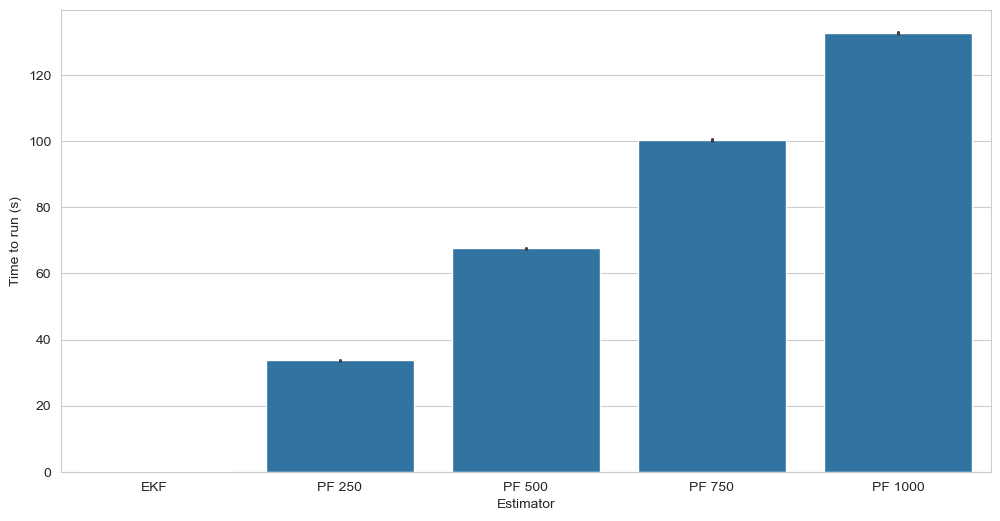

In [25]:
mean_time_run = np.average(time_arr_02.T, axis=0)
filters = ["EKF"]
num_particles = np.asarray([250, 500, 750, 1000])
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
df = pd.DataFrame(time_arr_02.T, columns=filters).melt(var_name='Estimator', value_name='Time to run (s)')

fig, ax = plt.subplots(figsize=(12,6))
sns.set_style("whitegrid") 
sns.barplot(df, x="Estimator", y="Time to run (s)", ax=ax);

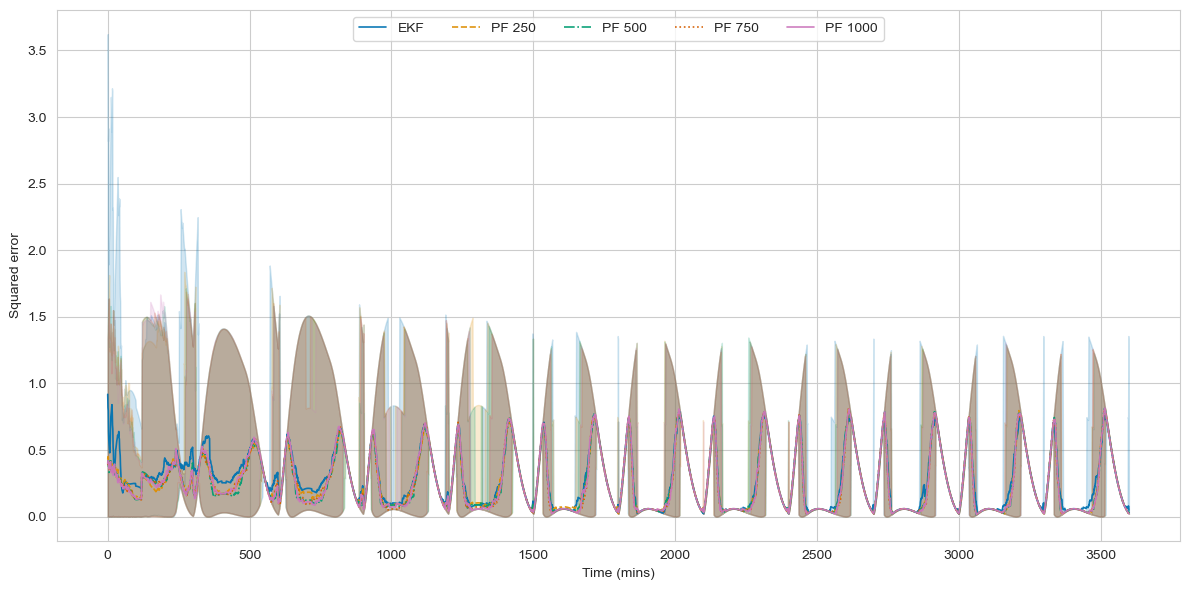

In [ ]:
mean_err = np.mean(error_arr_02, axis=1)
ci_low = np.percentile(error_arr_02, 2.5, axis=1)
ci_high = np.percentile(error_arr_02, 97.5, axis=1)
time = np.arange(mean_err.shape[1])
num_plots = 5 # 5 per subplot
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)

# fig, ax = plt.subplots(2,1, sharex='col', sharey=True, figsize=(12,5))
fig, ax = plt.subplots(figsize=(12,6))

for i in range(num_plots):
    ax.plot(time, mean_err[i], color=palette[i], linewidth=1.2, alpha=0.95, linestyle = ['-', '--', '-.', ':'][i % 4], label = f"")
    ax.fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18)
ax.set_ylabel('Squared error')
ax.legend(loc='upper center', ncols=num_plots)
ax.set_xlabel('Time (mins)')

# for i in range(num_plots, 2*num_plots):
#     ax[1].plot(time, mean_err[i], color=palette[i], linewidth=1.2, alpha=0.95, linestyle = ['-', '--', '-.', ':'][i % 4], label = filters[i])
#     ax[1].fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18)
# ax[1].set_xlabel('Time (mins)')
# ax[1].set_ylabel('Squared error')
# ax[1].legend(loc='upper center', ncols=num_plots)

fig.tight_layout()

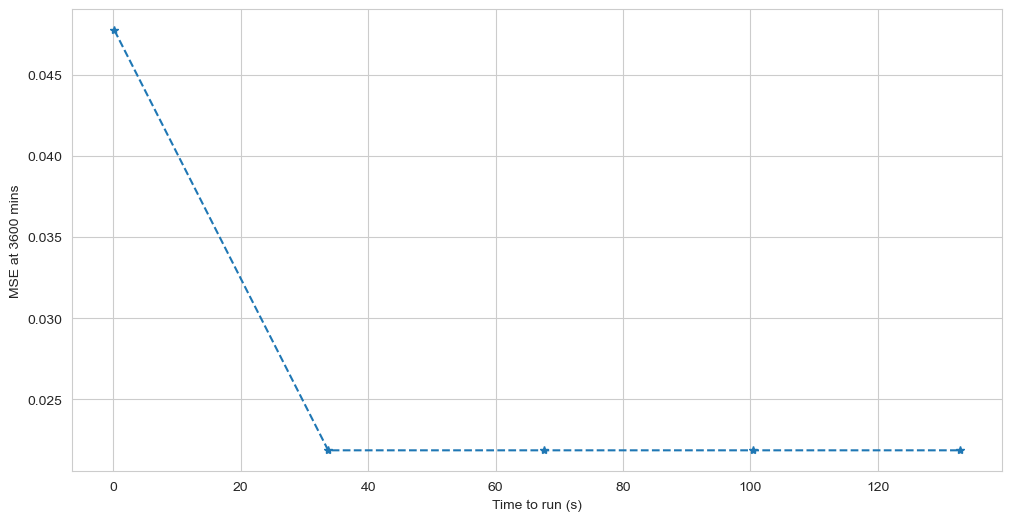

In [35]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(mean_time_run, mean_err[:,-1], linestyle='--', marker='*')
ax.set_xlabel('Time to run (s)')
ax.set_ylabel('MSE at 3600 mins');

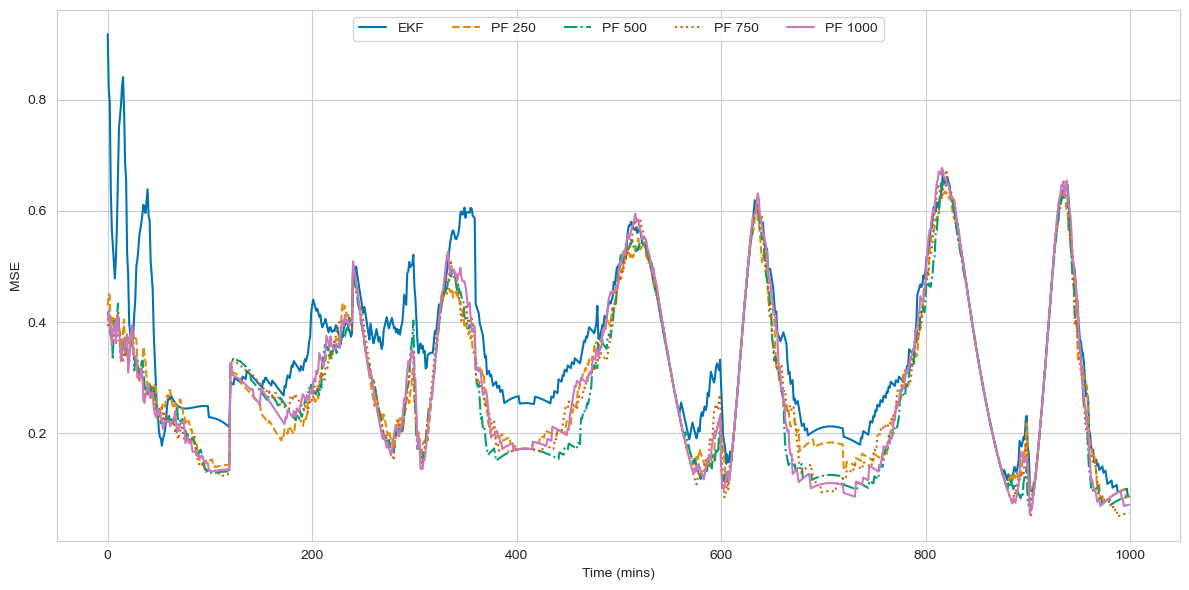

In [36]:
converge_time = 1000
fig, ax = plt.subplots(figsize=(12,6))

for i in range(num_filters):
    ax.plot(time[:converge_time], mean_err[i,:converge_time], color=palette[i], linestyle = ['-', '--', '-.', ':'][i % 4], label=filters[i])
ax.set_xlabel('Time (mins)')
ax.set_ylabel('MSE')
ax.legend(ncols=num_chosen, loc='upper center')
fig.tight_layout()